# Part 5 - Level 2: shrinking toward what the contact says

Part 4 ended on a complaint. Every hitter gets shrunk toward the **league mean**, which is the honest answer when you know nothing else about him — but you *do* know something else. You know how hard he hits the ball.

That matters because exit velocity and barrel rate settle down much faster than xwOBA does. At 40 plate appearances a hitter's xwOBA is still mostly noise, while his average exit velocity is already telling you something real. In the 30-100 PA range the peripherals actually predict next season **better than raw xwOBA does** (barrel rate r 0.244, exit velo r 0.227, raw xwOBA r 0.179). So they belong in the prior.

The version I tried first was to shrink toward the BART model's own xwOBA, and it went nowhere — the model is built from the same batted balls as the raw number, so there's nothing left over to shrink toward. This is the version that works. Everything here comes from `results/talent2/`.

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import numpy as np
import polars as pl
from IPython.display import Markdown, display

m = jload("talent2/talent2_metrics.json")
l2a, l2b = m["l2a"], m["l2b"]          # l2a = the reproduce-Phase-1 gate, l2b = the real thing
H = l2b["hypers"]

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: C:\Users\H-100\Desktop\python\xwobart
results:   C:\Users\H-100\Desktop\python\xwobart\results (exists)


## The model in one block

Rather than *regressing* xwOBA on the peripherals, all three stats are treated as **noisy measurements of correlated talents**:

- what we measure: `z = (xwOBA, avg EV, barrel rate)` ~ `N(true talents, S_i)`
- what's true:     `(theta, xi)` ~ `N(mu_season, Sigma_talent)`
- what we want:    `theta_hat = mu + Sigma (Sigma + S_i)^-1 (z - mu)`

`S_i` is how badly *this* hitter's three numbers are measured, bootstrapped from his own plate appearances. `Sigma_talent` is how the three talents co-vary across the league.

The whole thing is closed-form — no MCMC, no BART re-fit. It runs in about seven seconds. And the shape of that last line is worth staring at: when `S_i` is large (small sample), the estimate leans on `mu` and on whatever the *other* two stats imply. When `S_i` is small, it leans on the hitter's own xwOBA. The peripherals get a vote in exactly the situations where xwOBA can't be trusted.

## What the league looks like

First the piece that makes the whole thing work — how strongly the three talents actually travel together.

In [2]:
dims = ["xwOBA", "avg EV", "barrel rate"]
C = l2b["sigma_talent_corr"]
pl.DataFrame({"talent corr": dims,
              **{d: [round(C[i][j], 3) for i in range(3)] for j, d in enumerate(dims)}})

talent corr,xwOBA,avg EV,barrel rate
"""xwOBA""",1.0,0.776,0.712
"""avg EV""",0.776,1.0,0.824
"""barrel rate""",0.712,0.824,1.0


Strongly and positively, which is what baseball would tell you: hitters who square the ball up have higher xwOBA talent (+0.78 with exit velo, +0.71 with barrel rate). Those correlations are the entire mechanism — they're what lets a good exit-velo reading pull an xwOBA estimate upward.

And the sanity check that mattered most to me: the fitted xwOBA talent spread.

In [3]:
sd = np.sqrt(np.diag(np.array(H["Sigma"])))
display(pl.DataFrame([{"talent SD — xwOBA": round(float(sd[0]), 4),
                       "talent SD — avg EV (mph)": round(float(sd[1]), 2),
                       "talent SD — barrel rate": round(float(sd[2]), 4)}]))
pl.DataFrame([{"season": s, "mu xwOBA": round(mu[0], 4), "mu avg EV": round(mu[1], 2),
               "mu barrel rate": round(mu[2], 4)} for s, mu in zip(H["seasons"], H["mu"])])

talent SD — xwOBA,talent SD — avg EV (mph),talent SD — barrel rate
0.0312,2.42,0.0367


season,mu xwOBA,mu avg EV,mu barrel rate
2022,0.3034,87.91,0.0706
2023,0.3126,88.31,0.0761
2024,0.3094,88.12,0.074
2025,0.3166,88.55,0.0798


A completely different estimator, fit a completely different way (marginal MLE instead of method-of-moments), lands within 0.0016 of Part 4's league means in every season and mid-range on the spread — Part 4's per-season τ ran 0.0307–0.0323, and this fit's xwOBA talent SD of 0.0312 sits right inside that range. That's the "did I wire this up correctly" check, and it passed before I looked at a single validation number.

## What it does to actual hitters

This is where it gets fun. Here are low-PA seasons where the contact quality **disagrees** with the results — `next` is the following season's actual wOBA, which neither model got to see.

In [4]:
t2 = pl.read_parquet(RESULTS / "talent2" / "talent2_table.parquet")

def ex(name, season, note):
    d = t2.filter((pl.col("player_name") == name) & (pl.col("season") == season))
    assert d.height == 1, f"expected 1 row for {name} {season}, got {d.height}"
    r = d.row(0, named=True)
    return {"player": name, "season": season, "PA": r["PA"],
            "EV": round(r["avg_ev"], 1), "barrel": round(r["barrel_rate"], 3),
            "raw": round(r["xwoba_raw"], 3),
            "Phase 1": round(r["xwoba_talent"], 3),
            "Level 2": round(r["xwoba_talent2"], 3),
            "next": round(r["actual_woba"], 3), "": note}

pl.DataFrame([
    ex("Sal Stewart", 2025,    "hot line, elite contact"),
    ex("Stone Garrett", 2022,  "average line, good contact"),
    ex("Tyler Heineman", 2023, "hot line, no contact"),
    ex("César Salazar", 2024,  "<- a miss"),
])

player,season,PA,EV,barrel,raw,Phase 1,Level 2,next,
"""Sal Stewart""",2025,57,95.4,0.179,0.409,0.334,0.364,0.361,"""hot line, elite contact"""
"""Stone Garrett""",2022,76,93.9,0.109,0.307,0.305,0.337,0.42,"""average line, good contact"""
"""Tyler Heineman""",2023,42,77.4,0.0,0.332,0.32,0.275,0.292,"""hot line, no contact"""
"""César Salazar""",2024,31,82.9,0.0,0.347,0.318,0.274,0.352,"""<- a miss"""


Look at Stewart and Heineman together, because they're the argument in miniature. Both had hot lines in tiny samples — .409 in 57 PA, .332 in 42 PA — and Part 4 does roughly the same thing to both, hauling them back toward league average. But Stewart hit the ball 95.4 mph with a 17.9% barrel rate, and Heineman hit it **77.4 mph with zero barrels**. Level 2 declines to shrink Stewart all the way (.364, against a .361 next season) and calls Heineman's hot line what it was (.275, against .292).

Garrett is the quieter case: a perfectly average .307 line that the contact says was *unlucky*. Level 2 moves him up to .337 and he goes .420 the next year.

Then Salazar, who I put in on purpose. Same signal — 82.9 mph, no barrels, hot line — Level 2 marks him down to .274, and he posts .352. A real miss. The peripherals are information, not prophecy, and 31 PA is 31 PA.

Now the same mechanism across the whole population instead of four hand-picked names. What to look for: the correction fanning open as PA shrinks, with the colour carrying the sign.

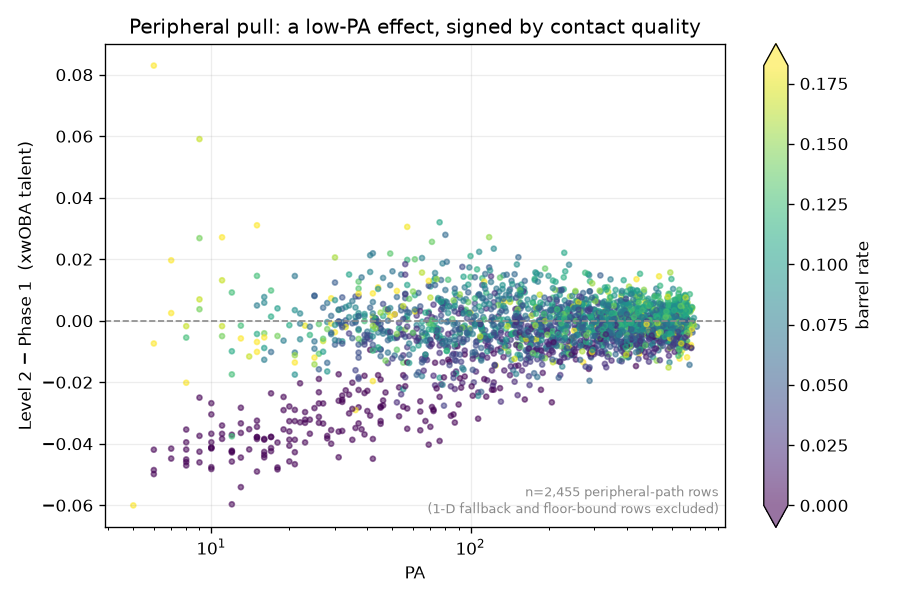

*Level 2 minus Phase 1 per player-season, against PA (log scale) — coloured by barrel rate.*

In [5]:
show_fig("talent2/figures/peripheral_pull.png",
         caption="Level 2 minus Phase 1 per player-season, against PA (log scale) — coloured by barrel rate.")

That's the whole population in one shot, and it's the picture I most wanted to see. The correction fans out as PA shrinks and collapses to nothing past ~300 PA — and it's cleanly **signed by colour**: yellow (high barrel rate) gets pulled up, purple gets pulled down. Nobody told it to do that; it falls out of those +0.78 / +0.71 correlations.

## The payoff — does it predict next season better?

Same test as Part 4: does the season-T estimate predict season-(T+1) **actual** wOBA?

In [6]:
def vrow(label, blk):
    return {"population": label, "n": blk["n"],
            "Level 2 r": round(blk["xwoba_talent2"]["r"], 4),
            "Phase 1 r": round(blk["xwoba_talent"]["r"], 4),
            "raw r": round(blk["xwoba_raw"]["r"], 4),
            "Savant r": round(blk["xwoba_savant"]["r"], 4)}

pl.DataFrame([vrow("pooled, PA_T >= 100", l2b["pooled_pa100"]),
              vrow("pooled, PA_T >= 30 (admits low-PA)", l2b["pooled_pa30"])])

population,n,Level 2 r,Phase 1 r,raw r,Savant r
"""pooled, PA_T >= 100""",1060,0.4908,0.4886,0.4835,0.4908
"""pooled, PA_T >= 30 (admits low…",1173,0.4698,0.4669,0.4454,0.4521


Level 2 beats Phase 1 in both populations. At 100+ PA it now **ties public Savant exactly** (0.4908 vs 0.4908) where Phase 1 was a hair behind, and once genuinely low-PA seasons are admitted it's ahead of Savant by 0.018.

But the pooled numbers undersell what's happening, because they average over a population where most hitters have plenty of PA and the peripherals have nothing to add. Split it by sample size.

In [7]:
pl.DataFrame([
    {"PA band": r["band"], "n": r["n"],
     "Level 2 r": round(r["xwoba_talent2"]["r"], 3),
     "Phase 1 r": round(r["xwoba_talent"]["r"], 3),
     "gain": round(r["xwoba_talent2"]["r"] - r["xwoba_talent"]["r"], 4),
     "raw r": round(r["xwoba_raw"]["r"], 3),
     "Savant r": round(r["xwoba_savant"]["r"], 3)}
    for r in l2b["by_band"]])

PA band,n,Level 2 r,Phase 1 r,gain,raw r,Savant r
"""[30,60)""",50,0.311,0.239,0.0718,0.209,0.211
"""[60,100)""",63,0.125,0.088,0.0365,0.11,0.128
"""[100,250)""",227,0.293,0.277,0.0166,0.278,0.293
"""[250,inf)""",833,0.512,0.512,-0.0,0.516,0.523


A clean monotone gradient: **+0.072 at 30-60 PA**, +0.037, +0.017, and then exactly nothing at 250+. The help arrives precisely where xwOBA is starving and disappears the moment it isn't. That's the design's central prediction, and it's the most convincing thing in this notebook.

One important footnote, because it contradicts Part 4. There I argued the by-band table was *meaningless* for judging shrinkage — within a narrow band reliability is near-constant, so the estimate is roughly affine in the raw number, and Pearson r is blind to affine transforms. That argument still holds for Part 4. It does **not** hold here: Level 2 isn't an affine function of raw xwOBA, because it's mixing in an independent signal. So these per-band gains are real, in a way Part 4's weren't. (They're also small-n — 50 and 63 hitters in the bottom two bands — so read the gradient, not the third decimal.)

## Now the part where I argue against myself

The pooled gain is +0.0029. That is small, and I don't want the by-band gradient above to paper over three things that all cut the other way.

In [8]:
pb = l2b["paired_bootstrap_pa30"]["delta_r"]
sp = l2b["split"]
gain = lambda blk: blk["xwoba_talent2"]["r"] - blk["xwoba_talent"]["r"]

display(pl.DataFrame([{
    "paired bootstrap (5,000 resamples, PA>=30)": f"mean gain {pb['mean']:+.4f}",
    "95% CI": f"[{pb['ci95'][0]:+.4f}, {pb['ci95'][1]:+.4f}]",
    "Level 2 better in": f"{pb['frac_better']:.1%} of resamples",
}]))
display(pl.DataFrame([
    {"held-out split": "select (22->23, 23->24) — choices made here", "n": sp["select"]["n"],
     "gain vs Phase 1": f"{gain(sp['select']):+.4f}"},
    {"held-out split": "confirm (24->25) — kept sealed", "n": sp["confirm"]["n"],
     "gain vs Phase 1": f"{gain(sp['confirm']):+.4f}"},
]))
pl.DataFrame([
    {"ablation": k,
     "select gain": f"{gain(l2b['ablations'][k]['select']):+.4f}",
     "confirm gain": f"{gain(l2b['ablations'][k]['confirm']):+.4f}"}
    for k in ("full_3d", "xwoba+avg_ev", "xwoba+barrel_rate")])

"paired bootstrap (5,000 resamples, PA>=30)",95% CI,Level 2 better in
"""mean gain +0.0029""","""[-0.0117, +0.0176]""","""64.1% of resamples"""


held-out split,n,gain vs Phase 1
"""select (22->23, 23->24) — choi…",787,"""+0.0063"""
"""confirm (24->25) — kept sealed""",386,"""-0.0034"""


ablation,select gain,confirm gain
"""full_3d""","""+0.0063""","""-0.0034"""
"""xwoba+avg_ev""","""+0.0020""","""+0.0050"""
"""xwoba+barrel_rate""","""+0.0035""","""-0.0065"""


1. **The confidence interval straddles zero.** [-0.0117, +0.0176], better in 64% of resamples. The point estimate likes Level 2; the sample can't actually distinguish it from no improvement.
2. **The held-out season reverses the sign.** I scored model choices on 2022→23 and 2023→24 and kept 2024→25 sealed. Select says +0.0063. Confirm says **-0.0034**. The pooled +0.0029 is an average of a win and a loss, and I didn't go back and tune anything to fix that.
3. **The ablations don't agree with each other.** On select, the full three-stat model wins, so that's what ships. On confirm, the exit-velo-only variant is the only positive one. No variant is consistently ahead.

So: the mechanism does what it was designed to do, in the regime it was designed for, with the sign it predicted, and it costs nothing at high PA. But one season of holdout contradicts it. It ships as an improvement **in expectation**, not a demonstrated one — and I'd rather say that plainly than quote +0.0029 on its own.

(A related trap worth naming: I originally treated "beats on r **and** on calibrated RMSE" as two pieces of evidence. It's one. For a fixed target set the calibrated RMSE is exactly `sd(target) * sqrt(1 - r^2)`, so beating on one *implies* beating on the other, always.)

## The test I was most worried about

Here's the failure mode that could have made all of this a mirage.

All three stats are computed from **the same batted balls**. A hitter who happens to square up a few extra balls in 40 PA gets an inflated xwOBA *and* an inflated exit velo *and* an inflated barrel rate, together — not because he's good, but because of the same lucky sample. If you naively regress xwOBA on the peripherals, the model can't tell that shared *noise* from shared *talent*. The coefficients inflate, the talent spread deflates, and you manufacture a beautiful low-PA improvement out of pure luck.

The joint-MVN setup is supposed to be immune, because `S_i` carries the off-diagonal terms that encode exactly that correlation. But "supposed to be" isn't evidence. So: refit with those off-diagonals zeroed — deliberately commit the error — and see whether the low-PA gain gets **bigger**. If it does, my gain was the artifact.

In [9]:
tw = l2b["offdiag_tripwire"]
pl.DataFrame([
    {"fit": "proper S_i (shipped)", "PA>=30 gain vs Phase 1": round(tw["gain_proper"], 4)},
    {"fit": "off-diagonals zeroed", "PA>=30 gain vs Phase 1": round(tw["gain_zeroed"], 4)},
    {"fit": "--> artifact gap", "PA>=30 gain vs Phase 1": round(tw["artifact_gap"], 4)},
])

fit,PA>=30 gain vs Phase 1
"""proper S_i (shipped)""",0.0029
"""off-diagonals zeroed""",-0.0101
"""--> artifact gap""",-0.013


**Clean, and not by a small margin.** Zeroing the off-diagonals doesn't inflate the gain — it *destroys* it, leaving a model **worse than Phase 1** (-0.0101). The artifact gap is -0.0130 against an alarm threshold of +0.005.

That means the shared-noise bookkeeping is genuinely load-bearing, and the +0.0029 isn't correlated noise being fitted. Had this come back positive I'd have withdrawn the low-PA claim entirely — which is the point of writing the tripwire *before* looking at the answer.

## A bug in Part 4 that this fixes

While rebuilding the machinery I ran a regression check — does the new code reproduce Phase 1? — and it failed in a way that turned out to be Part 4's fault, not the new code's.

Phase 4 measures how noisy a sample is by how much the hitter's outcomes vary from PA to PA. Consider a hitter with **two plate appearances who made two outs**. His outcomes don't vary at all. So the estimator computes "variance = zero", concludes the sample is perfectly precise, and reports his true talent as **exactly .000** — the worst hitter in history, stated with total confidence, off two outs.

In [10]:
ff = l2a["floor_fix"]
display(pl.DataFrame([{
    "rows changed by the variance floor": ff["n_floor_bound"],
    "of which Phase-1 variance was exactly 0": ff["n_phase1_se2_exactly_zero"],
    "median PA among them": int(ff["median_pa_floor_bound"]),
    "median move": round(ff["median_abs_diff_floor_bound"], 4),
    "largest move": round(ff["max_abs_diff_floor_bound"], 4),
}]))
pl.DataFrame([{"player": r["player_name"], "season": r["season"], "PA": r["PA"],
               "Phase 1": round(r["phase1"], 3), "Level 2": round(r["level2"], 3),
               "moved": round(r["moved"], 3)} for r in ff["biggest_moves"][:6]])

rows changed by the variance floor,of which Phase-1 variance was exactly 0,median PA among them,median move,largest move
136,7,11,0.0102,0.3085


player,season,PA,Phase 1,Level 2,moved
"""Trevor Rogers""",2025,2,0.0,0.309,0.309
"""Greg Jones""",2025,2,0.0,0.309,0.309
"""Chris Okey""",2023,2,0.0,0.305,0.305
"""Drew Romo""",2025,3,0.0,0.304,0.304
"""Tyler Naquin""",2023,3,0.0,0.3,0.3
"""Billy Hamilton""",2023,2,0.009,0.305,0.296


Trevor Rogers is a **pitcher**. He batted twice in 2025, made two outs, and Part 4 confidently assigned him a true-talent xwOBA of .000. Level 2 floors the measurement variance so no tiny sample can claim that kind of certainty, and puts him at .309 — league average, which is the honest answer when you know essentially nothing.

136 rows move; the median move is only 0.010, so this isn't a rewrite, it's a handful of pathological cases getting sane values. It does mean the "does it reproduce Phase 1?" check had to be scored on the 2,500 rows where the two models *should* agree (they correlate at 0.99950 there) with these 136 reported separately — a gate that passes by excluding the rows you deliberately changed is only honest if you show the rows.

## Intervals

The intervals narrow too, since the peripherals add information about the same underlying talent.

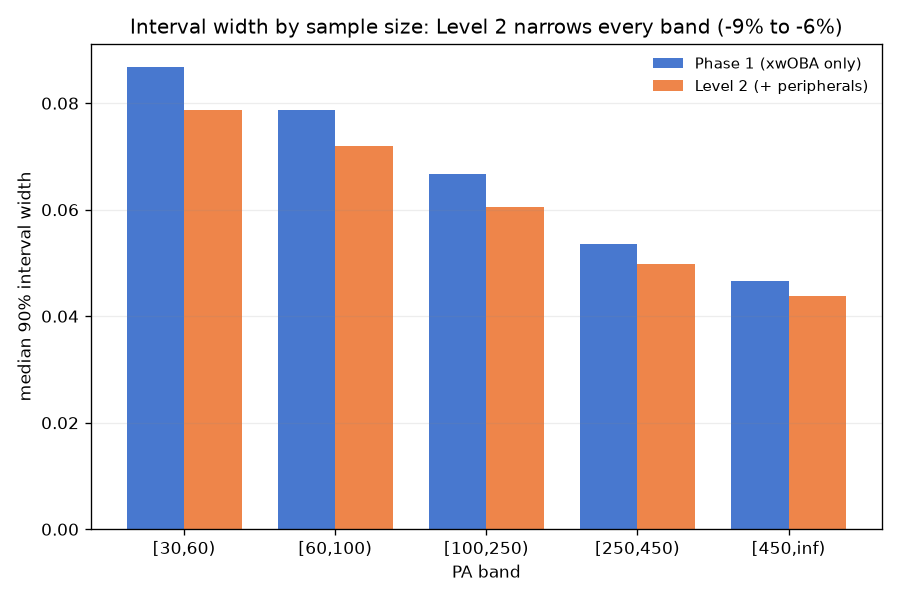

*Median 90% interval width by PA band — Level 2 (orange) sits inside Phase 1 (blue) in every band.*

In [11]:
show_fig("talent2/figures/interval_width_vs_pa.png",
         caption="Median 90% interval width by PA band — Level 2 (orange) sits inside Phase 1 (blue) in every band.")

In [12]:
pl.DataFrame([
    {"PA band": r["band"], "n": r["n"],
     "Phase 1 width": round(r["phase1"], 4), "Level 2 width": round(r["level2"], 4),
     "change": f"{100 * (r['level2'] / r['phase1'] - 1):+.1f}%"}
    for r in l2b["interval_width_by_pa"]])

PA band,n,Phase 1 width,Level 2 width,change
"""[30,60)""",239,0.0869,0.0788,"""-9.3%"""
"""[60,100)""",243,0.0787,0.072,"""-8.6%"""
"""[100,250)""",567,0.0667,0.0604,"""-9.4%"""
"""[250,450)""",609,0.0536,0.0498,"""-7.2%"""
"""[450,inf)""",654,0.0466,0.0437,"""-6.1%"""


I expected the narrowing to be concentrated at low PA. It isn't — it's a fairly uniform 6-9% everywhere. That's coherent with the model (peripherals say something about talent even when xwOBA is well measured), but I'd flag it as the least-verified claim here: at 250+ PA the model narrows the interval by 7% while moving the point estimate by *nothing*. Whether those intervals actually cover at the advertised rate is a coverage test I haven't run yet.

## Where this leaves things

Level 2 does what it set out to do. A hitter now regresses toward what his contact quality implies rather than toward .310, the help is concentrated exactly where the sample is thin, and the one test that could have exposed it as an artifact came back clean and decisive. It also quietly fixed a bug that had pitchers sitting at .000 true talent.

What it doesn't have is a confidently measured effect size. The honest version is "directionally right, small, and contradicted by one holdout season."

Three things I'd do next, roughly in order of how much I expect them to matter:

1. **Pool across seasons and age.** Every player-season here is estimated in isolation — a hitter's own previous years are simply ignored, which is a strange thing to throw away. I suspect this is worth more than the peripherals were.
2. **Fold in the surface uncertainty.** These intervals are still estimation-only; the BART surface term from Part 3 has never been combined in. That needs one re-fit that persists per-event draws, and it's what would let me finally validate coverage.
3. **Spray angle and handedness.** The 5-feature BART re-fit that the original v1 plan wanted, now measured against the ELPD anchor from Part 1.

Written up in full at `results/talent2/NOTES.md`, with the design in `docs/superpowers/specs/2026-07-19-xwobart-phase2-design-response.md`.

In [13]:
# guard: the numbers quoted in the prose above vs the artifacts — fails loudly on drift.
_gains = [round(gain(r), 3) for r in l2b["by_band"]]
assert _gains[0] == 0.072 and abs(_gains[-1]) < 0.005                  # "+0.072 at 30-60 ... nothing at 250+"
assert round(gain(l2b["pooled_pa30"]), 4) == 0.0029                    # "the pooled gain is +0.0029"
assert round(l2b["pooled_pa100"]["xwoba_talent2"]["r"], 4) == round(l2b["pooled_pa100"]["xwoba_savant"]["r"], 4) == 0.4908
assert round(l2b["pooled_pa30"]["xwoba_talent2"]["r"] - l2b["pooled_pa30"]["xwoba_savant"]["r"], 3) == 0.018
assert pb["ci95"][0] < 0 < pb["ci95"][1] and round(pb["frac_better"], 2) == 0.64
assert round(gain(sp["select"]), 4) == 0.0063 and round(gain(sp["confirm"]), 4) == -0.0034
_tw = l2b["offdiag_tripwire"]
assert round(_tw["gain_zeroed"], 4) == -0.0101 and round(_tw["artifact_gap"], 4) == -0.013
assert l2a["floor_fix"]["n_floor_bound"] == 136
_corr = l2b["sigma_talent_corr"]
assert round(_corr[0][1], 2) == 0.78 and round(_corr[0][2], 2) == 0.71
assert round(float(np.sqrt(H["Sigma"][0][0])), 4) == 0.0312
assert all(-0.10 < r["level2"] / r["phase1"] - 1 < -0.05 for r in l2b["interval_width_by_pa"])  # "uniform 6-9%"
print("prose numbers still match the artifacts")

prose numbers still match the artifacts
